<a href="https://colab.research.google.com/github/Levi-003/AI-training-Tasks/blob/main/Clustering_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import pdist

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Wholesale customers data.csv to Wholesale customers data (2).csv


In [ ]:
df = pd.read_csv("Wholesale customers data.csv")

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(440, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


In [ ]:
features = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

X = df[features]

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

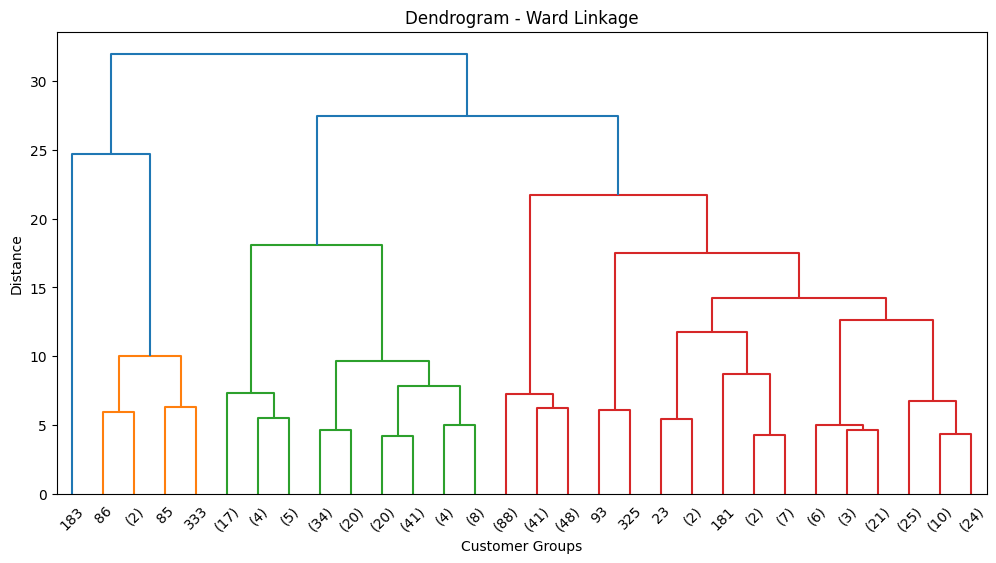

In [ ]:
linked_ward = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(12, 6))

dendrogram(
    linked_ward,
    truncate_mode="lastp",
    p=30
)

plt.title("Dendrogram - Ward Linkage")
plt.xlabel("Customer Groups")
plt.ylabel("Distance")

plt.show()

In [ ]:
methods = ["ward", "complete", "average"]

models = {}
labels = {}

In [ ]:
n_clusters = 3

for method in methods:

    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage=method
    )

    cluster_labels = model.fit_predict(X_scaled)

    models[method] = model
    labels[method] = cluster_labels

In [ ]:
comparison = pd.DataFrame({
    "Ward": labels["ward"],
    "Complete": labels["complete"],
    "Average": labels["average"]
})

print(comparison.head(20))

    Ward  Complete  Average
0      2         0        0
1      2         0        0
2      2         0        0
3      1         0        0
4      1         0        0
5      2         0        0
6      2         0        0
7      2         0        0
8      1         0        0
9      2         0        0
10     2         0        0
11     1         0        0
12     1         0        0
13     1         0        0
14     1         0        0
15     1         0        0
16     2         0        0
17     2         0        0
18     1         0        0
19     2         0        0


In [ ]:
for method in methods:

    print("\n", method.upper())

    print(
        pd.Series(labels[method])
        .value_counts()
        .sort_index()
    )


 WARD
0      6
1    281
2    153
Name: count, dtype: int64

 COMPLETE
0    429
1      1
2     10
Name: count, dtype: int64

 AVERAGE
0    434
1      1
2      5
Name: count, dtype: int64


In [ ]:
silhouette_results = {}

for method in methods:

    score = silhouette_score(
        X_scaled,
        labels[method]
    )

    silhouette_results[method] = score

    print(
        method.capitalize(),
        "Silhouette Score:",
        score
    )

Ward Silhouette Score: 0.2646091480214908
Complete Silhouette Score: 0.7115312932799636
Average Silhouette Score: 0.7675801420229833


In [ ]:
distance_matrix = pdist(X_scaled)

In [ ]:
cophenetic_results = {}

for method in methods:

    Z = linkage(
        X_scaled,
        method=method
    )

    c, coph_dists = cophenet(
        Z,
        distance_matrix
    )

    cophenetic_results[method] = c

    print(
        method.capitalize(),
        "Cophenetic Correlation:",
        c
    )

Ward Cophenetic Correlation: 0.41455685149572485
Complete Cophenetic Correlation: 0.8382968943303105
Average Cophenetic Correlation: 0.9338402303326109


In [ ]:
results = pd.DataFrame({
    "Linkage": methods,
    "Silhouette Score": [
        silhouette_results[m]
        for m in methods
    ],
    "Cophenetic Correlation": [
        cophenetic_results[m]
        for m in methods
    ]
})

print(results)

    Linkage  Silhouette Score  Cophenetic Correlation
0      ward          0.264609                0.414557
1  complete          0.711531                0.838297
2   average          0.767580                0.933840


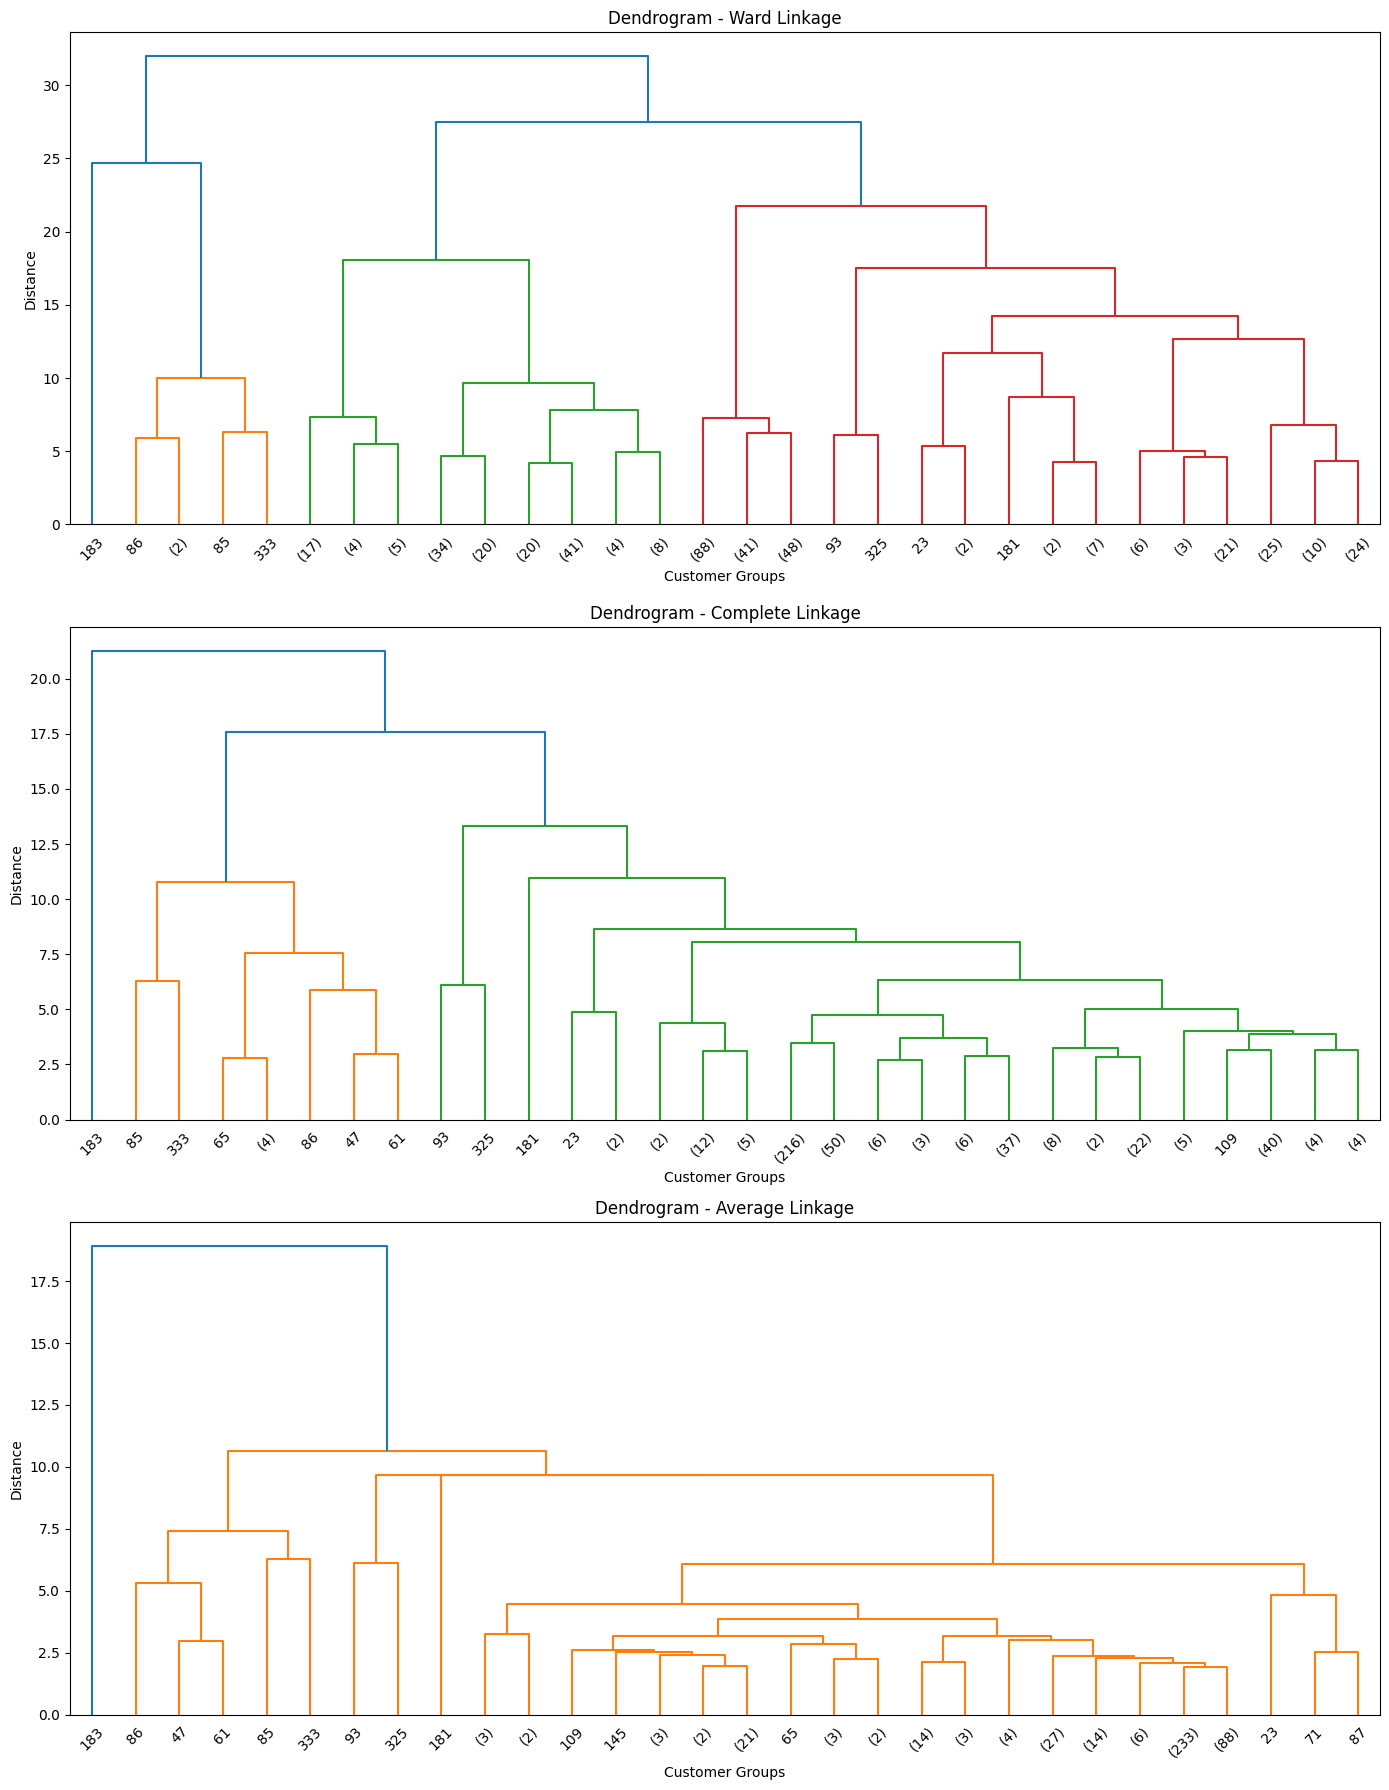

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

for ax, method in zip(axes, methods):

    Z = linkage(
        X_scaled,
        method=method
    )

    dendrogram(
        Z,
        truncate_mode="lastp",
        p=30,
        ax=ax
    )

    ax.set_title(f"Dendrogram - {method.capitalize()} Linkage")
    ax.set_xlabel("Customer Groups")
    ax.set_ylabel("Distance")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

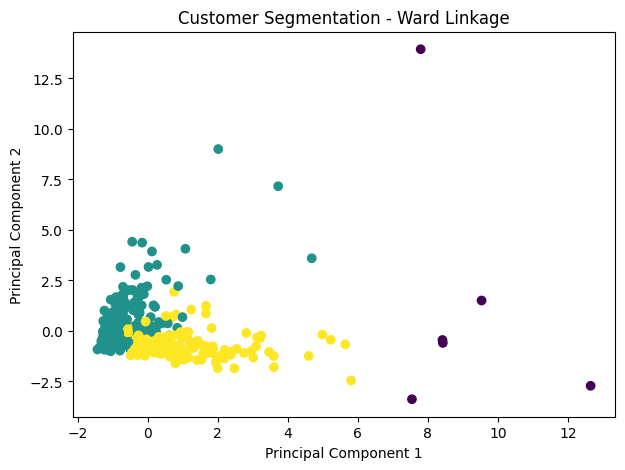

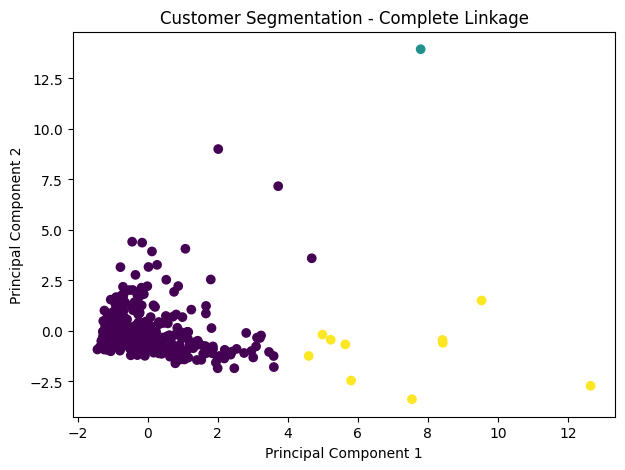

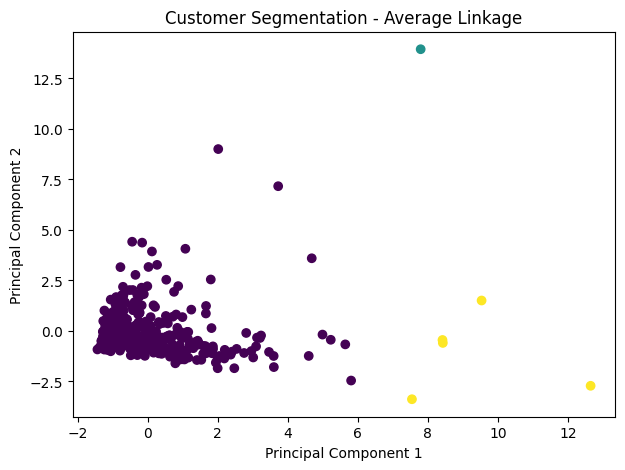

In [ ]:
for method in methods:

    plt.figure(figsize=(7, 5))

    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels[method]
    )

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")

    plt.title(
        f"Customer Segmentation - {method.capitalize()} Linkage"
    )

    plt.show()